# Pretraining analysis: DECIFRA and DECIFRA_MS (multistage training)

Compares the UKB pretraining runs of vanilla DECIFRA and the multistage DECIFRA_MS:
finds the best run of each, shows its losses and transition matrices, and tests whether the runs converge to one solution or to several (attractors).

## 0. Setup

In [1]:
import os, sys, glob

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from omegaconf import OmegaConf
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from scipy.stats import mannwhitneyu
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# repo root = first parent of the notebook dir that holds src/
ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "src")) and ROOT != os.path.dirname(ROOT):
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)

from src.settings import LOGS_ROOT, ASSETS_ROOT
from src.utils import zscore_np
from src.datasets.fbirn import load_data_hold
from src.datasets.ukb_ica import load_ica
from src.splits import pretraining_split
from src.models.DECIFRA import DECIFRA
from src.models.DECIFRA_MS import DECIFRA_MS

# pretraining experiments: name -> (log dir under LOGS_ROOT, model class, plot color)
EXPERIMENTS = {
    "DECIFRA": ("1_pretrain-ukb-DECIFRA", DECIFRA, "#2a78d6"),
    "DECIFRA_MS": ("1_pretrain-ukb-DECIFRA_MS-default", DECIFRA_MS, "#eb6834"),
}
OUT_DIR = os.path.join(ASSETS_ROOT, "analysis", "01_pretraining")  # figures, tables, matrix cache
RECOMPUTE = False                  # re-derive matrices even if cached
MATRIX_DATA = "ukb_val"            # "ukb_val": UKB pretraining validation split | "fbirn_hold"
N_SUBJECTS = 16                    # subjects to derive matrices for
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# attractor test: a 2-means split of the runs at one (subject, time) point
# counts as two solutions only if it is well separated and not just outliers
MIN_SILHOUETTE = 0.5
MIN_MINORITY = 0.2                 # smaller cluster holds >= 20% of the runs
MIN_SPLIT_FRAC = 0.1               # fewer split points -> one preferred solution
STICKY_MIN = 0.9                   # sticky run: 95% CI low of time in own group >= 90%

os.makedirs(OUT_DIR, exist_ok=True)
print(f"ROOT      {ROOT}\nLOGS_ROOT {LOGS_ROOT}\nOUT_DIR   {OUT_DIR}\nDEVICE    {DEVICE}")

/Users/ppopov1/miniconda3/envs/pile/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


ROOT      /Users/ppopov1/DECIFRA
LOGS_ROOT /Users/ppopov1/DECIFRA/assets/logs
OUT_DIR   /Users/ppopov1/DECIFRA/assets/analysis/01_pretraining
DEVICE    cpu


In [2]:
# chart chrome: recessive hairline grid and axes, muted tick labels
INK, MUTED = "#0b0b0b", "#898781"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK, "axes.titlesize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "lines.linewidth": 2,
})
DIVERGING = LinearSegmentedColormap.from_list("diverging", ["#2a78d6", "#f0efec", "#e34948"])
SEQUENTIAL = LinearSegmentedColormap.from_list("sequential", ["#cde2fb", "#6da7ec", "#256abf", "#0d366b"])
rng = np.random.default_rng(0)     # jitter for strip plots


def show(ax, m, cmap, vmin, vmax, title):
    """Matrix panel without grid or ticks."""
    im = ax.imshow(m, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="none")
    ax.set(title=title, xticks=[], yticks=[])
    ax.grid(False)
    return im


def save(fig, name):
    fig.savefig(os.path.join(OUT_DIR, f"{name}.png"))

In [3]:
def best_epoch(path):
    return int(open(os.path.join(path, "best_epoch.txt")).read().split()[0])


def load_runs(exp_dir):
    """One row per finished run, scored at its saved (best-by-val_loss) checkpoint."""
    rows, logs = [], {}
    for path in sorted(glob.glob(os.path.join(LOGS_ROOT, exp_dir, "[0-9][0-9]"))):
        if not os.path.exists(os.path.join(path, "best_epoch.txt")):
            continue
        run, ep = os.path.basename(path), best_epoch(path)
        df = pd.read_csv(os.path.join(path, "train_logs.csv"))
        at = df.loc[df.epoch == ep].iloc[0]
        rows.append({"run": run, "path": path, "best_epoch": ep,
                     "val_forecast_loss": at.val_forecast_loss,
                     "no_skill_loss": at.val_dumb_forecast_loss})
        logs[run] = df
    return pd.DataFrame(rows).set_index("run"), logs


def load_model(path, model_cls):
    """Pretrained model at its saved checkpoint, in eval mode."""
    cfg = OmegaConf.load(os.path.join(path, "model_config.yaml"))
    cfg.pretraining = True
    model = model_cls(cfg)
    ep = best_epoch(path)
    state = torch.load(os.path.join(path, "checkpoints", f"model_{ep}.pt"), map_location="cpu")
    model.load_state_dict(state)

    # staged models: restore the cross-channel scale used at that epoch
    if hasattr(model.BTP, "transfer_weight"):
        df = pd.read_csv(os.path.join(path, "train_logs.csv"))
        model.BTP.transfer_weight = float(df.loc[df.epoch == ep, "val_transfer_weight"].iloc[0])
    return model.to(DEVICE).eval()


def load_matrix_data(name):
    """Subjects no run was trained on, z-scored like the training input."""
    if name == "ukb_val":
        data = load_ica("hold")[0]["data"]
        data = data[pretraining_split(len(data))[1]]    # validation split of every pretraining run
    else:
        data = load_data_hold()[0]["data"]              # FBIRN holdout
    return zscore_np(data[:N_SUBJECTS], axis=1)


@torch.no_grad()
def derive_matrices(model, data, batch_size=16):
    """Transition matrices (S, T, C, C); the identity DECIFRA_MS adds is removed."""
    out = []
    for i in range(0, len(data), batch_size):
        x = torch.tensor(data[i:i + batch_size], dtype=torch.float32, device=DEVICE)
        out.append(model(x)[1]["matrices"].cpu().numpy())
    mats = np.concatenate(out)

    if isinstance(model, DECIFRA_MS):
        mats -= np.eye(mats.shape[-1], dtype=mats.dtype)
    return mats

In [4]:
def split_runs(X):
    """2-means over runs at one (subject, time) point; X: (n_runs, C*C)."""
    labels = KMeans(n_clusters=2, n_init=5, random_state=0).fit_predict(X)
    minority = np.bincount(labels, minlength=2).min() / len(labels)
    sil = silhouette_score(X, labels) if minority > 0 else 0.0
    return labels, sil, minority


def attractor_analysis(mats):
    """Cluster |M| across runs at every (subject, time); mats: (n_runs, S, T, C, C)."""
    n_runs, S, T = mats.shape[:3]
    X = np.abs(mats).reshape(n_runs, S * T, -1)
    labels, sil, minority = map(np.array, zip(*(split_runs(X[:, i]) for i in range(S * T))))
    two = (sil >= MIN_SILHOUETTE) & (minority >= MIN_MINORITY)

    # run groups from how often two runs share a cluster (label-invariant)
    lab = labels[two] if two.any() else labels
    coassign = (lab[:, :, None] == lab[:, None, :]).mean(axis=0)
    groups = fcluster(linkage(squareform(1 - coassign, checks=False), "average"), 2, "maxclust") - 1
    if np.bincount(groups, minlength=2).argmax() == 1:
        groups = 1 - groups                          # A = the larger group
    return dict(labels=labels.reshape(S, T, n_runs), sil=sil, minority=minority,
                two=two.reshape(S, T), coassign=coassign, groups=groups)


def stickiness(a, n_boot=1000):
    """Per run: share of split points spent in its own group (95% CI from resampling
    subjects) and how often it changes group between consecutive time points."""
    two, g = a["two"], a["groups"]

    # orient every split to agree with the run groups, then mark who sits in its own group
    flip = (a["labels"] == g).mean(-1) < 0.5
    stay = np.where(flip[..., None], a["labels"] != g, a["labels"] == g)   # (S, T, n_runs)

    # share of split points in own group, bootstrapped over subjects
    n_split, n_stay = two.sum(1), (stay & two[..., None]).sum(1)
    idx = np.random.default_rng(0).integers(0, len(n_split), (n_boot, len(n_split)))
    boot = n_stay[idx].sum(1) / np.maximum(n_split[idx].sum(1), 1)[:, None]

    # group changes between consecutive split points
    pair = two[:, 1:] & two[:, :-1]
    switch = (stay[:, 1:] != stay[:, :-1])[pair].mean(0) if pair.any() else np.full(len(g), np.nan)

    ok = n_split.sum() > 0                          # no split points -> nothing to measure
    return pd.DataFrame({
        "group": np.array(["A", "B"])[g],
        "stickiness": n_stay.sum(0) / n_split.sum() if ok else np.nan,
        "ci_low": np.percentile(boot, 2.5, axis=0) if ok else np.nan,
        "ci_high": np.percentile(boot, 97.5, axis=0) if ok else np.nan,
        "switch_rate": switch,
    })


def verdict(a, st):
    if a["two"].mean() < MIN_SPLIT_FRAC:
        return "one preferred solution"
    loose = int((st.ci_low < STICKY_MIN).sum())
    return "two sticky solutions (attractors)" if loose == 0 else f"two solutions, {loose} of {len(st)} runs switch"

## 1. Pretraining metrics

Each run is scored by the validation forecast MSE of its saved checkpoint (`best_epoch.txt`, the
epoch with the lowest total validation loss); the best run of a model has the lowest score.

In [5]:
runs, logs, best = {}, {}, {}
for name, (exp_dir, _, _) in EXPERIMENTS.items():
    runs[name], logs[name] = load_runs(exp_dir)
    best[name] = runs[name].val_forecast_loss.idxmin()

summary = pd.DataFrame({name: {
    "runs": len(r), "mean": r.val_forecast_loss.mean(), "std": r.val_forecast_loss.std(),
    "best run": best[name], "best": r.val_forecast_loss.min(), "no-skill": r.no_skill_loss.mean(),
} for name, r in runs.items()}).T
summary.to_csv(os.path.join(OUT_DIR, "summary.csv"))
summary

,runs,mean,std,best run,best,no-skill
DECIFRA,20,0.482897,0.005353,19,0.478173,0.568377
DECIFRA_MS,10,0.415116,0.000815,14,0.41408,0.568377


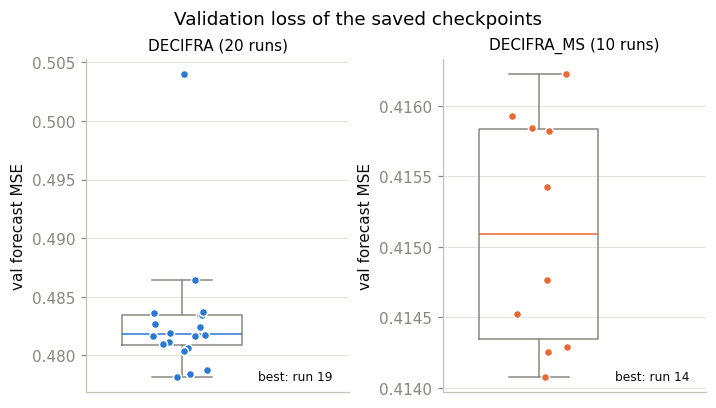

In [6]:
# small multiples: each model on its own y-scale
fig, axes = plt.subplots(1, len(runs), figsize=(3.2 * len(runs), 3.6), constrained_layout=True)
for ax, (name, r) in zip(axes, runs.items()):
    color, y = EXPERIMENTS[name][2], r.val_forecast_loss
    ax.boxplot(y, widths=0.5, showfliers=False, medianprops=dict(color=color),
               boxprops=dict(color=MUTED), whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED))
    ax.scatter(1 + rng.uniform(-0.12, 0.12, len(y)), y, s=28, color=color, edgecolor="white", zorder=3)
    ax.annotate(f"best: run {best[name]}", (1.32, y.min()), va="center", fontsize=8, color=INK)
    ax.set(title=f"{name} ({len(y)} runs)", xticks=[], xlim=(0.6, 1.7), ylabel="val forecast MSE")
fig.suptitle("Validation loss of the saved checkpoints")
save(fig, "best_losses")

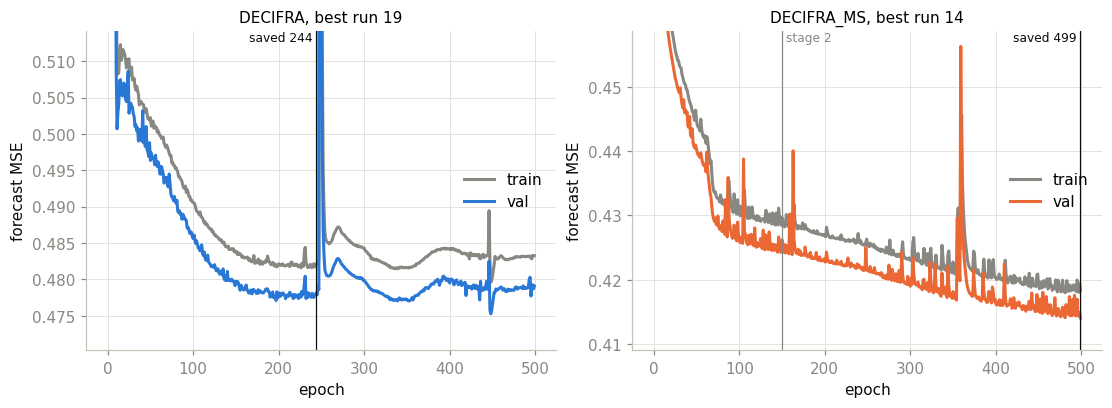

In [7]:
fig, axes = plt.subplots(1, len(runs), figsize=(5 * len(runs), 3.6), constrained_layout=True)
for ax, name in zip(axes, runs):
    run, color = best[name], EXPERIMENTS[name][2]
    df, ep = logs[name][run], runs[name].loc[run, "best_epoch"]
    ax.plot(df.epoch, df.train_forecast_loss, color=MUTED, label="train")
    ax.plot(df.epoch, df.val_forecast_loss, color=color, label="val")

    # zoom past the initial drop; mark the saved epoch (and the stage switch)
    tail = df[["train_forecast_loss", "val_forecast_loss"]].iloc[20:]
    ax.set_ylim(tail.min().min() - 0.005, tail.quantile(0.98).max() + 0.005)
    top = ax.get_ylim()[1]
    ax.axvline(ep, color=INK, linewidth=0.8)
    ax.text(ep, top, f"saved {ep} ", ha="right", va="top", fontsize=8, color=INK)
    if "stage" in df:
        switch = df.epoch[df.stage == 1].min()
        ax.axvline(switch, color=MUTED, linewidth=0.8)
        ax.text(switch, top, " stage 2", va="top", fontsize=8, color=MUTED)
    ax.set(title=f"{name}, best run {run}", xlabel="epoch", ylabel="forecast MSE")
    ax.legend(frameon=False, loc="center right")
save(fig, "best_loss_curves")

## 2. Transition matrices and attractors

Matrices are derived for `N_SUBJECTS` subjects no run was trained on: by default the UKB pretraining
validation split (`MATRIX_DATA = "ukb_val"`, the same subjects for every run, 490 time points), or the
FBIRN holdout (`"fbirn_hold"`). Inputs are z-scored over time like the training input; for DECIFRA_MS
the identity term is removed, leaving its learned cross-channel part.

**Attractor test.** At every (subject, time) point, the |M| of all runs are split into two clusters
(2-means). A split counts as two solutions when it is well separated (silhouette ≥ `MIN_SILHOUETTE`)
and the smaller cluster is more than a few outliers (≥ `MIN_MINORITY` of the runs). Runs are then
grouped by how often they share a cluster.

**Stickiness.** Each split is oriented to agree with the run groups. A run's stickiness is the share
of split points where it sits in its own group (95% CI from resampling subjects); its switch rate is
how often it changes group between consecutive time points. A run is sticky when the CI lower bound is
≥ `STICKY_MIN`. The groups come from the same splits, so this measures consistency, not a held-out test.

In [8]:
X_eval = load_matrix_data(MATRIX_DATA)
print(MATRIX_DATA, X_eval.shape)

mats = {}
for name, (exp_dir, model_cls, _) in EXPERIMENTS.items():
    per_run = []
    for run, row in runs[name].iterrows():
        cache = os.path.join(OUT_DIR, f"matrices_{MATRIX_DATA}_{name}_{run}.npy")
        if RECOMPUTE or not os.path.exists(cache) or np.load(cache, mmap_mode="r").shape[0] != len(X_eval):
            np.save(cache, derive_matrices(load_model(row.path, model_cls), X_eval))
        per_run.append(np.load(cache))
    mats[name] = np.stack(per_run)                  # (n_runs, S, T, C, C)
    print(name, mats[name].shape)

ukb_val (16, 490, 53)
DECIFRA (20, 16, 490, 53, 53)
DECIFRA_MS (10, 16, 490, 53, 53)


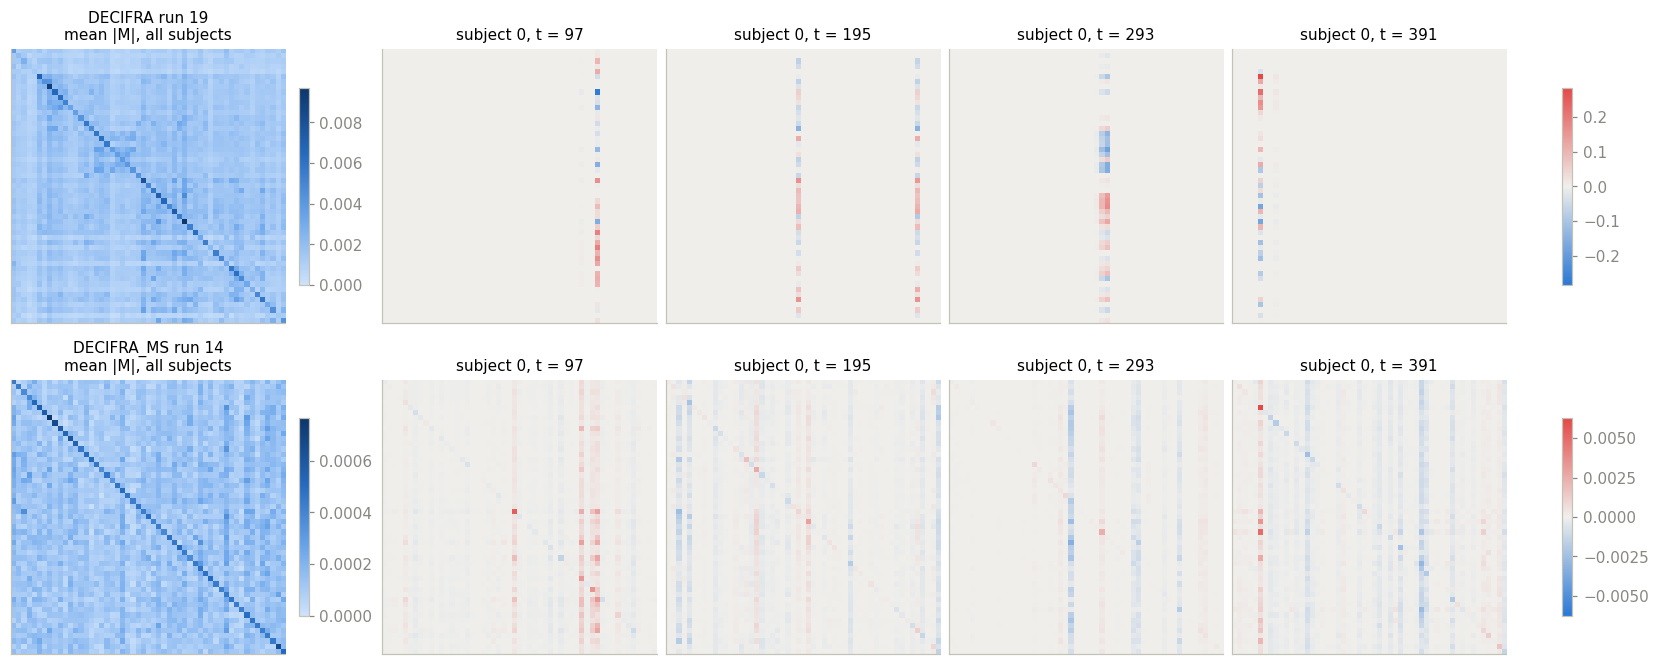

In [9]:
SUBJECT = 0
TIMES = np.linspace(0, X_eval.shape[1] - 1, 6)[1:-1].astype(int)   # 4 time points across the scan
fig, axes = plt.subplots(len(mats), 1 + len(TIMES), figsize=(3 * (1 + len(TIMES)), 3 * len(mats)),
                         constrained_layout=True)
for row, name in zip(axes, mats):
    m = mats[name][runs[name].index.get_loc(best[name])]
    im = show(row[0], np.abs(m).mean(axis=(0, 1)), SEQUENTIAL, 0, None,
              f"{name} run {best[name]}\nmean |M|, all subjects")
    fig.colorbar(im, ax=row[0], shrink=0.7)

    lim = np.abs(m[SUBJECT, TIMES]).max()
    for ax, t in zip(row[1:], TIMES):
        im = show(ax, m[SUBJECT, t], DIVERGING, -lim, lim, f"subject {SUBJECT}, t = {t}")
    fig.colorbar(im, ax=row[1:], shrink=0.7)
save(fig, f"best_matrices_{MATRIX_DATA}")

In [10]:
attr = {name: attractor_analysis(m) for name, m in mats.items()}
sticky = {name: stickiness(a).set_axis(runs[name].index) for name, a in attr.items()}

# per-run table: saved epoch, loss, group and stickiness (for fine-tuning-based selection later)
table = pd.concat({name: runs[name].drop(columns="path").join(sticky[name]) for name in runs}, names=["model"])
table.to_csv(os.path.join(OUT_DIR, f"runs_{MATRIX_DATA}.csv"))

pd.DataFrame({name: {
    "split points": f"{a['two'].sum()} ({a['two'].mean():.1%})",
    "runs A / B": "{} / {}".format(*np.bincount(a["groups"], minlength=2)),
    "min stickiness (CI low)": sticky[name].ci_low.min(),
    "mean switch rate": sticky[name].switch_rate.mean(),
    "best run in": sticky[name].loc[best[name], "group"],
    "verdict": verdict(a, sticky[name]),
} for name, a in attr.items()}).T

,split points,runs A / B,min stickiness (CI low),mean switch rate,best run in,verdict
DECIFRA,7384 (94.2%),10 / 10,0.995923,0.001289,B,two sticky solutions (attractors)
DECIFRA_MS,33 (0.4%),7 / 3,0.868421,NaN,B,one preferred solution


In [ ]:
for name, a in attr.items():
    m, r, st, color = mats[name], runs[name], sticky[name], EXPERIMENTS[name][2]
    order = np.argsort(a["groups"], kind="stable")
    fig, ((ax_split, ax_co, ax_st), (ax_loss, ax_a, ax_b)) = plt.subplots(2, 3, figsize=(13, 7.4),
                                                                          constrained_layout=True)

    # every (subject, time) split: how balanced vs how separated
    ax_split.scatter(a["minority"] + rng.uniform(-0.01, 0.01, len(a["sil"])), a["sil"],
                     s=6, alpha=0.3, color=color, edgecolor="none")
    ax_split.axhline(MIN_SILHOUETTE, color=MUTED, linewidth=0.8)
    ax_split.axvline(MIN_MINORITY, color=MUTED, linewidth=0.8)
    ax_split.set(xlim=(0, 0.53), xlabel="minority fraction of runs", ylabel="silhouette",
                 title=f"2-means splits: {a['two'].mean():.1%} count as two")

    # how often two runs land in the same cluster
    used = "split points" if a["two"].any() else "all points"
    im = show(ax_co, a["coassign"][np.ix_(order, order)], SEQUENTIAL, 0, 1, f"run co-assignment ({used})")
    ax_co.set_xticks(range(len(r)))
    ax_co.set_xticklabels(r.index[order], fontsize=6, rotation=90)
    ax_co.set_yticks(range(len(r)))
    ax_co.set_yticklabels(r.index[order], fontsize=6)
    fig.colorbar(im, ax=ax_co, shrink=0.7)

    # stickiness: share of split points each run spends in its own group
    s = st.iloc[order]
    ax_st.errorbar(range(len(s)), s.stickiness, yerr=[s.stickiness - s.ci_low, s.ci_high - s.stickiness],
                   fmt="o", color=color, ecolor=MUTED, elinewidth=1, capsize=2, markersize=5)
    ax_st.axhline(STICKY_MIN, color=MUTED, linewidth=0.8)
    ax_st.set(ylim=(0, 1.02), ylabel="time in own group",
              title=f"stickiness, 95% CI ({a['two'].sum()} split points)")
    ax_st.set_xticks(range(len(s)))
    ax_st.set_xticklabels(s.index, fontsize=6, rotation=90)

    # are the groups equally good forecasters?
    losses = [r.val_forecast_loss[a["groups"] == g] for g in (0, 1)]
    for g, y in enumerate(losses):
        ax_loss.scatter(g + rng.uniform(-0.1, 0.1, len(y)), y, s=28, color=color, edgecolor="white")
    p = mannwhitneyu(*losses).pvalue if min(map(len, losses)) > 1 else np.nan
    ax_loss.set(xticks=[0, 1], xticklabels=[f"A ({len(losses[0])})", f"B ({len(losses[1])})"],
                xlim=(-0.5, 1.5), ylabel="val forecast MSE", title=f"loss by group (Mann-Whitney p = {p:.2f})")

    # mean |M| of each group
    means = [np.abs(m[a["groups"] == g]).mean(axis=(0, 1, 2)) if (a["groups"] == g).any()
             else np.zeros(m.shape[-2:]) for g in (0, 1)]
    vmax = max(x.max() for x in means)
    for ax, g, x in zip((ax_a, ax_b), "AB", means):
        im = show(ax, x, SEQUENTIAL, 0, vmax, f"group {g}: mean |M|")
    fig.colorbar(im, ax=[ax_a, ax_b], shrink=0.7)

    fig.suptitle(f"{name}: {verdict(a, st)}")
    save(fig, f"attractors_{MATRIX_DATA}_{name}")

**Reading the verdict** (thresholds in the setup cell)
- *one preferred solution*: runs agree at nearly every point; 2-means only peels off single runs.
- *two sticky solutions (attractors)*: every run stays in its group (CI lower bound ≥ `STICKY_MIN`) for the whole scan (paper Fig. 9A).
- *two solutions, k runs switch*: those runs move between the groups over time (as seen with AAL3).

`runs_<MATRIX_DATA>.csv` in `OUT_DIR` holds each run's saved epoch, loss, group, stickiness and switch rate.